## Importación de librerias

In [ ]:
import os
import gc
import numpy as np
import pandas as pd
from google.colab import drive

## Carga de los datos

El dataset pesa demasiado, vamos a cargarlo desde google drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
archivo = "/content/drive/MyDrive/Colab Notebooks/data/AIS_2024_12_25.csv"

In [ ]:
print("Existe:", os.path.exists(archivo))
print("Tamaño MB:", os.path.getsize(archivo) / (1024**2))

with open(archivo, "rb") as f:
    total_lineas = sum(1 for _ in f) - 1

print("Líneas físicas del archivo:", total_lineas)

Existe: True
Tamaño MB: 601.6908912658691
Líneas físicas del archivo: 5727812


Vamos a cargar el AIS crudo

In [ ]:
df_raw = pd.read_csv(
    archivo,
    dtype={"MMSI": "string"},
    low_memory=False,
    engine="c"
)

df_raw.shape


(5727812, 17)

In [ ]:
df_raw

,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,IMO,CallSign,VesselType,Status,Length,Width,Draft,Cargo,TransceiverClass
0,366969140,2024-12-25T00:00:00,29.76375,-95.09826,0.3,42.1,240.0,NITA E,IMO0008192,WTH5609,31.0,12.0,16.0,6.0,2.1,31.0,A
1,367473150,2024-12-25T00:00:01,29.77014,-93.92837,0.2,162.0,108.0,CAPT.VINTON J.CROSBY,NaN,WDN5239,33.0,15.0,108.0,12.0,2.1,33.0,A
2,368361890,2024-12-25T00:00:01,47.63053,-122.33978,0.0,208.3,0.0,PTONTO,IMO0000000,WDP5271,37.0,NaN,15.0,4.0,NaN,NaN,B
3,367082130,2024-12-25T00:00:03,18.44770,-66.09109,0.0,166.8,82.0,TIMOTHY MCALLISTER,IMO8997895,WDC8133,31.0,0.0,31.0,10.0,3.8,31.0,A
4,367679730,2024-12-25T00:00:05,47.65685,-122.37962,0.0,176.0,511.0,MARTHA,NaN,WDI2591,30.0,NaN,18.0,5.0,NaN,NaN,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5727807,338926439,2024-12-25T21:03:03,13.42399,144.66357,0.0,0.0,150.0,CGC MYRTLE HAZARD,NaN,NMHD,51.0,5.0,46.0,7.0,3.0,51.0,A
5727808,338926439,2024-12-25T21:15:05,13.42400,144.66358,0.0,0.0,150.0,CGC MYRTLE HAZARD,NaN,NMHD,51.0,5.0,46.0,7.0,3.0,51.0,A
5727809,338926439,2024-12-25T21:24:05,13.42402,144.66355,0.0,0.0,149.0,CGC MYRTLE HAZARD,NaN,NMHD,51.0,5.0,46.0,7.0,3.0,51.0,A
5727810,338926439,2024-12-25T22:00:06,13.42404,144.66356,0.0,0.0,149.0,CGC MYRTLE HAZARD,NaN,NMHD,51.0,5.0,46.0,7.0,3.0,51.0,A


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5727812 entries, 0 to 5727811
Data columns (total 17 columns):
 #   Column            Dtype  
---  ------            -----  
 0   MMSI              string 
 1   BaseDateTime      object 
 2   LAT               float64
 3   LON               float64
 4   SOG               float64
 5   COG               float64
 6   Heading           float64
 7   VesselName        object 
 8   IMO               object 
 9   CallSign          object 
 10  VesselType        float64
 11  Status            float64
 12  Length            float64
 13  Width             float64
 14  Draft             float64
 15  Cargo             float64
 16  TransceiverClass  object 
dtypes: float64(11), object(5), string(1)
memory usage: 742.9+ MB


## Selección y limpieza

In [ ]:
cols = [
    "MMSI",
    "BaseDateTime",
    "LAT",
    "LON",
    "SOG",
    "COG",
    "VesselType",
    "Length",
    "Width"
]

In [ ]:
df = df_raw[cols].copy()

In [ ]:
df["BaseDateTime"] = pd.to_datetime(df["BaseDateTime"], errors="coerce")


In [ ]:
df = df.dropna(subset=["MMSI", "BaseDateTime", "LAT", "LON", "SOG", "COG"])
df = df.drop_duplicates()

In [ ]:
df = df[df["LAT"].between(-90, 90)]
df = df[df["LON"].between(-180, 180)]
df = df[df["SOG"].between(0, 60)]
df = df[df["COG"].between(0, 360)]

In [ ]:
df = df.rename(columns={"VesselType": "ship_type"})

In [ ]:
df["ship_type"].value_counts()

,count
ship_type,
37.0,1318996
31.0,1058627
52.0,897934
30.0,417816
70.0,347131
...,...
120.0,365
16.0,362
77.0,307


In [ ]:
df.shape

(5714824, 9)

## Agrupación por tipo de barco

0–19 → No definido / Reservado

20–29 → WIG

30–39 → Special Craft

40–49 → High Speed Craft

50–59 → Service / Support

60–69 → Passenger

70–79 → Cargo

80–89 → Tanker

90–99 → Other

MarineTraffic. (n.d.). What is the significance of the AIS Shiptype or Vessel type number? [Support article]. Recuperado el 10 de marzo de 2026, de https://support.marinetraffic.com/en/articles/9552866-what-is-the-significance-of-the-ais-shiptype-or-vessel-type-number

In [ ]:
def group_ship_type(x):

    if pd.isna(x):
        return "Unknown"

    x = int(x)

    if 0 <= x <= 19:
        return "Undefined"

    elif 20 <= x <= 29:
        return "WIG"

    elif 30 <= x <= 39:
        return "Special_Craft"

    elif 40 <= x <= 49:
        return "High_Speed"

    elif 50 <= x <= 59:
        return "Service"

    elif 60 <= x <= 69:
        return "Passenger"

    elif 70 <= x <= 79:
        return "Cargo"

    elif 80 <= x <= 89:
        return "Tanker"

    elif 90 <= x <= 99:
        return "Other"

    else:
        return "Other"

In [ ]:
df["ship_type_group"] = df["ship_type"].apply(group_ship_type)

In [ ]:
df["ship_type_group"].value_counts()

,count
ship_type_group,
Special_Craft,3276092
Service,1142884
Cargo,436654
Passenger,361786
Tanker,224345
Other,163753
Undefined,76331
High_Speed,23453
WIG,8474


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5714824 entries, 0 to 5727811
Data columns (total 10 columns):
 #   Column           Dtype         
---  ------           -----         
 0   MMSI             string        
 1   BaseDateTime     datetime64[ns]
 2   LAT              float64       
 3   LON              float64       
 4   SOG              float64       
 5   COG              float64       
 6   ship_type        float64       
 7   Length           float64       
 8   Width            float64       
 9   ship_type_group  object        
dtypes: datetime64[ns](1), float64(7), object(1), string(1)
memory usage: 479.6+ MB


Ordenamos las trayectorias

In [ ]:
df = df.sort_values(["MMSI","BaseDateTime"]).reset_index(drop=True)

In [ ]:
df["MMSI"].nunique()

14348

Diferencia temporal entre mensajes AIS

In [ ]:
df["delta_t"] = df.groupby("MMSI")["BaseDateTime"].diff().dt.total_seconds()


Cambio de velocidad

In [ ]:
df["delta_sog"] = df.groupby("MMSI")["SOG"].diff().abs()

## Construimos trayectorias

In [ ]:
df["delta_t"].describe()

,delta_t
count,5.700476e+06
mean,1.782338e+02
std,5.033936e+02
min,0.000000e+00
25%,7.000000e+01
50%,1.190000e+02
75%,1.800000e+02
max,8.208600e+04


Los mensajes suelen llegar cada 1-3 minutos.

El max es de 17,7h hay gaps grandes y tendremos que cortar trayectorias para estudiar los comportamientos por separado.

Escogemos un umbral de 30 minutos para evitar unir movimientos que en realidad no son continuos.

Ribeiro, C. V., Paes, A., & de Oliveira, D. (2023). AIS-based maritime anomaly traffic detection: A review. Expert Systems with Applications, 231, Article 120561. https://www.sciencedirect.com/science/article/abs/pii/S0957417423010631

In [ ]:
GAP_THRESHOLD = 1800  # 30 min
df["new_trajectory"] = (df["delta_t"] > GAP_THRESHOLD).fillna(False).astype(int)
df["trajectory_id"] = df.groupby("MMSI")["new_trajectory"].cumsum()

print(df[["MMSI", "BaseDateTime", "delta_t", "trajectory_id"]].head())

  MMSI        BaseDateTime  delta_t  trajectory_id
0    0 2024-12-25 00:03:47      NaN              0
1    0 2024-12-25 00:05:47    120.0              0
2    0 2024-12-25 00:07:47    120.0              0
3    0 2024-12-25 00:10:50    183.0              0
4    0 2024-12-25 00:21:20    630.0              0


Como podemos ver, para el MMSI 0, lo que tenemos aquí son entradas las cuales no superan los 1800 segundos, lo cual tienen el mismo id de trayectoria

In [ ]:
df["trajectory_id"].nunique()

20

El máximo de trayectorias por barco es de 20

Distancia entre posiciones - **distancia Haversine** ya que conisdera la curvatura de la Tierra

In [ ]:
def haversine_np(lat1, lon1, lat2, lon2):
    R = 6371.0  # km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

### Generador de ventanas deslizantes

Para determinar los minutos de paso y de ventana, vamos a hacer un estudio de los hiperparámetros.

In [ ]:
def generate_segments_time(df, window_minutes=10, step_minutes=5, min_points=5):
    window_delta = pd.Timedelta(minutes=window_minutes)
    step_delta = pd.Timedelta(minutes=step_minutes)

    for (mmsi, traj), group in df.groupby(["MMSI", "trajectory_id"]):
        group = group.sort_values("BaseDateTime")

        if len(group) < min_points:
            continue

        start_time = group["BaseDateTime"].iloc[0]
        end_time = group["BaseDateTime"].iloc[-1]

        current_start = start_time

        while current_start + window_delta <= end_time:
            current_end = current_start + window_delta

            segment = group[
                (group["BaseDateTime"] >= current_start) &
                (group["BaseDateTime"] < current_end)
            ]

            if len(segment) >= min_points:
                yield segment

            current_start += step_delta

Evaluación de configuraciones

In [ ]:
import numpy as np
import pandas as pd
import time

def evaluate_window_configs(df, configs, min_points=5):
    results = []

    for window_minutes, step_minutes in configs:
        start_clock = time.time()

        n_segments = 0
        points_per_segment = []
        durations = []

        for seg in generate_segments_time(
            df,
            window_minutes=window_minutes,
            step_minutes=step_minutes,
            min_points=min_points
        ):
            n_segments += 1
            points_per_segment.append(len(seg))

            duration_sec = (
                seg["BaseDateTime"].iloc[-1] - seg["BaseDateTime"].iloc[0]
            ).total_seconds()
            durations.append(duration_sec)

        elapsed = time.time() - start_clock

        if len(points_per_segment) > 0:
            results.append({
                "window_minutes": window_minutes,
                "step_minutes": step_minutes,
                "n_segments": n_segments,
                "mean_points": float(np.mean(points_per_segment)),
                "median_points": float(np.median(points_per_segment)),
                "min_points_observed": int(np.min(points_per_segment)),
                "max_points_observed": int(np.max(points_per_segment)),
                "mean_duration_sec": float(np.mean(durations)),
                "time_sec": float(elapsed)
            })

    return pd.DataFrame(results)

Evaluación con una pequeña muestra

In [ ]:
sample_mmsi = df["MMSI"].dropna().unique()[:50]
df_sample = df[df["MMSI"].isin(sample_mmsi)].copy()

print("Shape muestra:", df_sample.shape)
print("Número de barcos en muestra:", df_sample["MMSI"].nunique())

Shape muestra: (15028, 14)
Número de barcos en muestra: 50


In [ ]:
configs = [
    (5, 2),
    (10, 5),
    (15, 5),
    (20, 10)
]

In [ ]:
window_eval = evaluate_window_configs(df_sample, configs, min_points=5)
window_eval.sort_values(["n_segments", "mean_points"], ascending=[False, False])

,window_minutes,step_minutes,n_segments,mean_points,median_points,min_points_observed,max_points_observed,mean_duration_sec,time_sec
2,15,5,4239,7.025006,5.0,5,16,742.760085,7.521081
3,20,10,3149,7.943792,6.0,5,21,1000.339790,3.305294
1,10,5,1439,7.339819,8.0,5,12,505.734538,6.217516
0,5,2,618,5.035599,5.0,5,7,267.365696,17.850885


In [ ]:
window_eval["points_ok"] = window_eval["mean_points"] >= 5
window_eval = window_eval.sort_values(
    by=["points_ok", "mean_points", "n_segments"],
    ascending=[False, False, False]
)

window_eval

,window_minutes,step_minutes,n_segments,mean_points,median_points,min_points_observed,max_points_observed,mean_duration_sec,time_sec,points_ok
3,20,10,3149,7.943792,6.0,5,21,1000.339790,3.305294,True
1,10,5,1439,7.339819,8.0,5,12,505.734538,6.217516,True
2,15,5,4239,7.025006,5.0,5,16,742.760085,7.521081,True
0,5,2,618,5.035599,5.0,5,7,267.365696,17.850885,True


Al final nos quedamos con ventana de 15 min y paso de 5 min porque:

15 min de ventana: da suficiente contexto para capturar el comportamiento sin mezclar demasiadas cosas distintas en un mismo segmento.

5 min de paso: genera solapamiento, pero nos aporta buena resolución temporal sin multiplicar excesivamente los segmentos.

5 segmentos resultantes: volumen de datos manejable y representativo.

En resumen, la combinación más equilibrada entre detalle, representatividad y coste computacional.



In [ ]:
window_minutes = 15
step_minutes = 5
min_points = 5


In [ ]:
gen = generate_segments_time(
    df,
    window_minutes=window_minutes,
    step_minutes=step_minutes,
    min_points=min_points
)

first_segment = next(gen)

print(first_segment[["MMSI", "BaseDateTime", "LAT", "LON", "SOG", "COG"]].head())
print("Número de puntos:", len(first_segment))
print("Duración real:", first_segment["BaseDateTime"].iloc[-1] - first_segment["BaseDateTime"].iloc[0])

   MMSI        BaseDateTime       LAT        LON  SOG    COG
8     0 2024-12-25 00:38:25  32.70722 -117.23848  0.1  238.0
9     0 2024-12-25 00:40:26  32.70721 -117.23845  0.0    0.0
10    0 2024-12-25 00:42:25  32.70719 -117.23845  1.0   40.1
11    0 2024-12-25 00:44:25  32.70715 -117.23851  0.0    0.0
12    0 2024-12-25 00:47:26  32.70721 -117.23857  0.6  137.1
Número de puntos: 5
Duración real: 0 days 00:09:01


Se utilizan ventanas temporales deslizantes en lugar de ventanas basadas en número de puntos, ya que el muestreo AIS es irregular y una ventana basada en puntos podría representar duraciones muy diferentes.

## Features

In [ ]:
def segment_features(segment):
    speed = segment["SOG"].values
    course = segment["COG"].values
    delta_t = segment["delta_t"].values
    lat = segment["LAT"].values
    lon = segment["LON"].values

    # distancia recorrida
    if len(lat) > 1:
        distance = haversine_np(lat[:-1], lon[:-1], lat[1:], lon[1:]).sum()
    else:
        distance = 0.0

    # cambio de rumbo circular
    if len(course) > 1:
        delta_course = np.abs(np.diff(course))
        delta_course = np.minimum(delta_course, 360 - delta_course)
    else:
        delta_course = np.array([0.0])

    # tiempos válidos
    valid_dt = delta_t[1:] if len(delta_t) > 1 else np.array([np.nan])
    valid_dt = np.where((valid_dt <= 0) | np.isnan(valid_dt), np.nan, valid_dt)

    # aceleración
    delta_speed = np.diff(speed) if len(speed) > 1 else np.array([0.0])

    turning_rate = delta_course / valid_dt if len(delta_course) > 0 else np.array([0.0])
    acceleration = delta_speed / valid_dt if len(delta_speed) > 0 else np.array([0.0])

    return {
        "MMSI": segment["MMSI"].iloc[0],
        "trajectory_id": segment["trajectory_id"].iloc[0],

        "speed_mean": np.nanmean(speed),
        "speed_std": np.nanstd(speed),
        "speed_max": np.nanmax(speed),

        "delta_course_mean": np.nanmean(delta_course),
        "delta_course_max": np.nanmax(delta_course),

        "turning_rate_mean": np.nanmean(turning_rate),
        "turning_rate_max": np.nanmax(turning_rate),

        "acceleration_mean": np.nanmean(acceleration),
        "acceleration_max": np.nanmax(acceleration),

        "delta_t_mean": np.nanmean(delta_t),
        "delta_t_max": np.nanmax(delta_t),

        "distance_km": distance,
        "duration": (segment["BaseDateTime"].iloc[-1] - segment["BaseDateTime"].iloc[0]).total_seconds(),

        "ship_type": segment["ship_type_group"].mode()[0],

        "lat_mean": segment["LAT"].mean(),
        "lon_mean": segment["LON"].mean(),
        "lat_start": segment["LAT"].iloc[0],
        "lon_start": segment["LON"].iloc[0],
        "lat_end": segment["LAT"].iloc[-1],
        "lon_end": segment["LON"].iloc[-1]
    }

Comprobación

In [ ]:
test_features = segment_features(first_segment)
test_features

{'MMSI': '0',
 'trajectory_id': np.int64(0),
 'speed_mean': np.float64(0.34),
 'speed_std': np.float64(0.39799497484264795),
 'speed_max': np.float64(1.0),
 'delta_course_mean': np.float64(84.82499999999999),
 'delta_course_max': np.float64(137.1),
 'turning_rate_mean': np.float64(0.6092161207321155),
 'turning_rate_max': np.float64(1.0082644628099173),
 'acceleration_mean': np.float64(0.0006396247143211423),
 'acceleration_max': np.float64(0.008403361344537815),
 'delta_t_mean': np.float64(192.0),
 'delta_t_max': np.float64(419.0),
 'distance_km': np.float64(0.021124664344499194),
 'duration': 541.0,
 'ship_type': 'Service',
 'lat_mean': np.float64(32.707196),
 'lon_mean': np.float64(-117.238492),
 'lat_start': np.float64(32.70722),
 'lon_start': np.float64(-117.23848),
 'lat_end': np.float64(32.70721),
 'lon_end': np.float64(-117.23857)}

## Creación dataset

In [ ]:
df

,MMSI,BaseDateTime,LAT,LON,SOG,COG,ship_type,Length,Width,ship_type_group,delta_t,delta_sog,new_trajectory,trajectory_id
0,0,2024-12-25 00:03:47,32.70726,-117.23855,0.1,58.8,51.0,82.0,12.0,Service,NaN,NaN,0,0
1,0,2024-12-25 00:05:47,32.70723,-117.23850,0.0,0.0,51.0,82.0,12.0,Service,120.0,0.1,0,0
2,0,2024-12-25 00:07:47,32.70720,-117.23848,0.0,0.0,51.0,82.0,12.0,Service,120.0,0.0,0,0
3,0,2024-12-25 00:10:50,32.70717,-117.23849,0.0,0.0,51.0,82.0,12.0,Service,183.0,0.0,0,0
4,0,2024-12-25 00:21:20,32.70721,-117.23852,0.0,0.0,51.0,82.0,12.0,Service,630.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5714819,999999999,2024-12-25 23:46:50,26.14934,-80.10962,0.0,360.0,90.0,0.0,0.0,Other,182.0,0.0,0,0
5714820,999999999,2024-12-25 23:49:52,26.14935,-80.10962,0.0,360.0,90.0,0.0,0.0,Other,182.0,0.0,0,0
5714821,999999999,2024-12-25 23:52:48,26.14935,-80.10962,0.0,360.0,90.0,0.0,0.0,Other,176.0,0.0,0,0
5714822,999999999,2024-12-25 23:55:51,26.14936,-80.10963,0.0,360.0,90.0,0.0,0.0,Other,183.0,0.0,0,0


In [ ]:
output_csv = "/content/drive/MyDrive/Colab Notebooks/data/segments_dataset_con_id.csv"
chunk_size = 500

if os.path.exists(output_csv):
    os.remove(output_csv)

buffer = []
first_chunk = True
segment_id = 0

for seg in generate_segments_time(df, window_minutes=15, step_minutes=5):
    row = segment_features(seg)
    row["segment_id"] = segment_id
    buffer.append(row)
    segment_id += 1

    if len(buffer) >= chunk_size:
        chunk_df = pd.DataFrame(buffer)

        cols = ["segment_id"] + [c for c in chunk_df.columns if c != "segment_id"]
        chunk_df = chunk_df[cols]

        chunk_df.to_csv(
            output_csv,
            mode="w" if first_chunk else "a",
            header=first_chunk,
            index=False
        )

        first_chunk = False
        buffer = []
        del chunk_df
        gc.collect()

if buffer:
    chunk_df = pd.DataFrame(buffer)

    cols = ["segment_id"] + [c for c in chunk_df.columns if c != "segment_id"]
    chunk_df = chunk_df[cols]

    chunk_df.to_csv(
        output_csv,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    del chunk_df
    gc.collect()

print("Dataset guardado en:", output_csv)
print("Número total de segmentos:", segment_id)

Dataset guardado en: /content/drive/MyDrive/Colab Notebooks/data/segments_dataset_con_id.csv
Número total de segmentos: 1523121


El coste computacional elevado se concentra en la fase offline de generación de ventanas y extracción de características. Sin embargo, una vez entrenado el modelo, la evaluación de nuevas observaciones se realiza en tiempo casi real, ya que únicamente requiere procesar una ventana temporal reciente.

In [ ]:
segments_df = pd.read_csv(output_csv)
segments_df.fillna(segments_df.mean(numeric_only=True), inplace=True)
segments_df.to_csv(output_csv, index=False)

segments_df.shape

(1523121, 23)

El dataset final contiene más de 1.5 millones de segmentos de trayectorias, lo que permite un análisis robusto del comportamiento marítimo y la detección de anomalías en condiciones cercanas a escenarios reales.

In [ ]:
segments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1523121 entries, 0 to 1523120
Data columns (total 23 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   segment_id         1523121 non-null  int64  
 1   MMSI               1523121 non-null  int64  
 2   trajectory_id      1523121 non-null  int64  
 3   speed_mean         1523121 non-null  float64
 4   speed_std          1523121 non-null  float64
 5   speed_max          1523121 non-null  float64
 6   delta_course_mean  1523121 non-null  float64
 7   delta_course_max   1523121 non-null  float64
 8   turning_rate_mean  1523121 non-null  float64
 9   turning_rate_max   1523121 non-null  float64
 10  acceleration_mean  1523121 non-null  float64
 11  acceleration_max   1523121 non-null  float64
 12  delta_t_mean       1523121 non-null  float64
 13  delta_t_max        1523121 non-null  float64
 14  distance_km        1523121 non-null  float64
 15  duration           1523121 non-n

In [ ]:
segments_df.head()

,segment_id,MMSI,trajectory_id,speed_mean,speed_std,speed_max,delta_course_mean,delta_course_max,turning_rate_mean,turning_rate_max,...,delta_t_max,distance_km,duration,ship_type,lat_mean,lon_mean,lat_start,lon_start,lat_end,lon_end
0,0,0,0,0.34,0.397995,1.0,84.825000,137.1,0.609216,1.008264,...,419.0,0.021125,541.0,Service,32.707196,-117.238492,32.70722,-117.23848,32.70721,-117.23857
1,1,0,0,0.48,0.479166,1.4,87.625000,178.2,0.544857,0.973770,...,183.0,0.018756,660.0,Service,32.707170,-117.238528,32.70716,-117.23848,32.70716,-117.23853
2,2,0,0,0.64,0.523832,1.4,127.650000,178.2,0.889722,1.447059,...,183.0,0.016201,600.0,Service,32.707180,-117.238534,32.70716,-117.23857,32.70721,-117.23851
3,3,0,0,0.45,0.330404,0.8,54.240000,98.8,0.552916,1.568254,...,570.0,0.047246,599.0,Service,32.707165,-117.238500,32.70712,-117.23855,32.70724,-117.23852
4,4,0,0,0.30,0.350510,0.8,39.083333,98.8,0.423090,1.568254,...,181.0,0.023781,722.0,Service,32.707199,-117.238524,32.70716,-117.23854,32.70724,-117.23853


## Visualizaciones

Trayectoria de un barco

In [ ]:
df["MMSI"].value_counts().head()

,count
MMSI,
368084240,1284
367001790,1274
367531220,1270
367653630,1265
366772780,1264


Voy a coger el MMSI 368084240 ya que tiene muchos puntos y ver cómo están distribuidos.

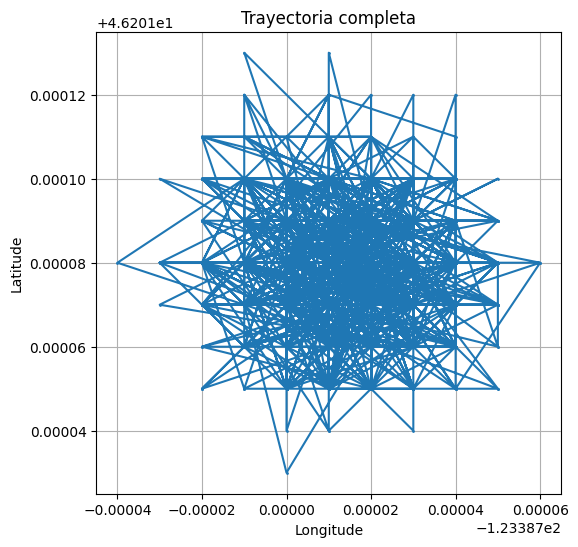

In [ ]:
mmsi_example = "368084240"

traj = df[df["MMSI"] == mmsi_example].sort_values("BaseDateTime")

plt.figure(figsize=(6,6))
plt.plot(traj["LON"], traj["LAT"], marker="o", markersize=1)
plt.title("Trayectoria completa")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid()
plt.show()

In [ ]:
traj = df[df["MMSI"] == mmsi_example]
print(len(traj))
traj.head()

1284


,MMSI,BaseDateTime,LAT,LON,SOG,COG,ship_type,Length,Width,ship_type_group,delta_t,delta_sog,new_trajectory,trajectory_id
4145466,368084240,2024-12-25 00:00:01,46.20111,-123.38698,0.0,235.7,52.0,34.0,10.0,Service,NaN,NaN,0,0
4145467,368084240,2024-12-25 00:01:02,46.20108,-123.38696,0.0,236.0,52.0,34.0,10.0,Service,61.0,0.0,0,0
4145468,368084240,2024-12-25 00:02:03,46.20111,-123.38696,0.0,236.3,52.0,34.0,10.0,Service,61.0,0.0,0,0
4145469,368084240,2024-12-25 00:03:04,46.20112,-123.38699,0.0,235.8,52.0,34.0,10.0,Service,61.0,0.0,0,0
4145470,368084240,2024-12-25 00:04:11,46.20109,-123.38702,0.0,235.6,52.0,34.0,10.0,Service,67.0,0.0,0,0


La detección de anomalías se basa en patrones de comportamiento sin incorporar conocimiento contextual del entorno. Por tanto, ciertas maniobras normales en zonas portuarias pueden ser clasificadas como anomalías, lo que pone de manifiesto la necesidad de integrar información geoespacial en futuros trabajos.


In [ ]:
import folium

m = folium.Map(location=[traj["LAT"].mean(), traj["LON"].mean()], zoom_start=6)

coords = list(zip(traj["LAT"], traj["LON"]))

folium.PolyLine(coords).add_to(m)

m

Como podemos ver en este caso se encuentra en zona portuaria. Más adelante, en el Kmeans agruparemos por zonas.

Ventana sobre trayectoria

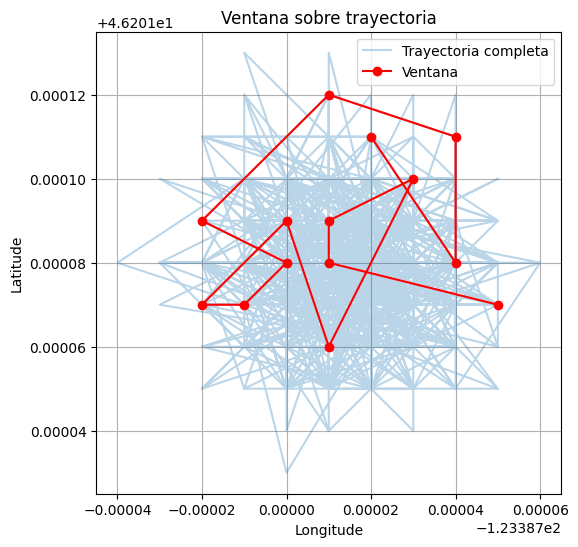

In [ ]:
# coger una trayectoria
traj = df[df["MMSI"] == mmsi_example].sort_values("BaseDateTime")

# coger una ventana
gen = generate_segments_time(traj, window_minutes=15, step_minutes=5)
seg = next(gen)

plt.figure(figsize=(6,6))

# trayectoria completa
plt.plot(traj["LON"], traj["LAT"], alpha=0.3, label="Trayectoria completa")

# ventana
plt.plot(seg["LON"], seg["LAT"], color="red", marker="o", label="Ventana")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.title("Ventana sobre trayectoria")
plt.grid()
plt.show()

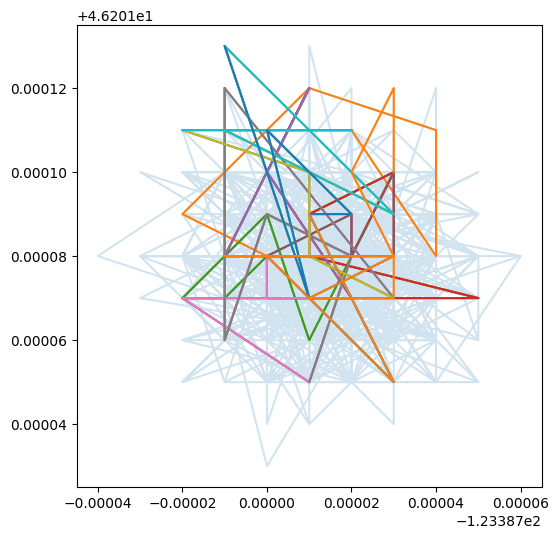

In [ ]:
gen = generate_segments_time(traj, window_minutes=15, step_minutes=5)

plt.figure(figsize=(6,6))
plt.plot(traj["LON"], traj["LAT"], alpha=0.2)

for i, seg in enumerate(gen):
    if i > 10:
        break
    plt.plot(seg["LON"], seg["LAT"])

plt.show()